# Stage A — Inter-sensor consistency (§8.1.3) + baseline comparison (§8.1.4)

Two independent stress tests of the Stage A merge run side-by-side because both
chew on the same held-out window and the same per-sensor grids inside the
merged NetCDFs:

* **§8.1.3 — inter-sensor R² per region**, *before* the §7.4.1 soft
  calibration (raw GRIDDED_DIR slot files) and *after* (soft-calibrated
  per-sensor grids in MERGED_DIR).  v3.6 promoted Himawari L2 and L3 to
  first-class fusion sensors, so both the pre- and post-correction tables
  carry them as separate channels — the pre/post head-to-head is now apples-
  to-apples per level.  The Nguyen 2025 §3.1.4 / §5.2 numbers are the
  published baseline; the pass criterion is that post-correction R² lifts by
  ≥ +0.10 in every region for at least one sensor pair.
* **§8.1.4 — baseline comparison at AERONET pixels**:
  - B1: best-single-sensor (VIIRS NOAA-20 by §5.1)
  - B2: Gupta-2024-style equal-weight merge of the same soft-calibrated grids
  - reference: thesis TC-weighted (§7.5) merged product

  The pass criterion is that the merged product beats every baseline on
  R / RMSE / %EE at *at least one* AERONET station for *at least one* season.
  B3 (Ahn 2021 NE Asia composite) and B4 (Nguyen 2025 daily Himawari RANSAC
  vs PM₂.₅) are §11 stretch items and are not exercised here.

The helpers all live in [validate.py](validate.py):
`inter_sensor_consistency(source=...)`, `baseline_comparison`,
`extract_aeronet_pairs`, `compute_metrics`.


## 0. Setup

In [1]:
from pathlib import Path
from datetime import date
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from config import AERONET_SITES, TEST_START, TEST_END
from validate import (
    inter_sensor_consistency, baseline_comparison,
    extract_aeronet_pairs, compute_metrics,
    NGUYEN2025_R2_BASELINES, DEFAULT_SENSOR_PAIRS,
)

start, end = TEST_START, TEST_END
print(f'Validation window: {start} → {end}')


Validation window: 2025-01-01 → 2026-04-30


## 1. §8.1.3 inter-sensor R² — gridded (raw) vs merged (corrected)

`inter_sensor_consistency` accepts a `source` flag:

* `source='gridded'` reads raw per-sensor AOD from GRIDDED_DIR (Stage A2
  output, before §7.4.1 soft calibration).  Himawari is split into
  `AOD_himawari_l2` and `AOD_himawari_l3`.
* `source='merged'` reads the soft-calibrated per-sensor AOD from MERGED_DIR
  (after §7.4.1 `MERRA-2 = α·sat + β` per stratum).  As of v3.6 there is no
  pre-fusion L2/L3 merge — both `AOD_himawari_l2` and `AOD_himawari_l3` are
  exposed independently, exactly as in the gridded source.

We compute daily means at every Envisoft station pixel (matching Nguyen 2025
§3.1.4), then for each (sensor_a, sensor_b, region) regress all station-days
in that region and report R² alongside the Nguyen 2025 baseline (note: the
published baseline is for a single Himawari product, so Himawari rows here
have `R2_baseline = NaN`).  We pass the same pair list to both sources so the
ΔR² head-to-head is per-level.


In [2]:
# Shared pair list: L2 and L3 are first-class sensors in both gridded and
# merged sources (v3.6), so the same set is used for the pre/post head-to-head.
sensor_pairs = [
    ('AOD_modis_maiac',  'AOD_himawari_l2'),
    ('AOD_modis_maiac',  'AOD_himawari_l3'),
    ('AOD_viirs_noaa20', 'AOD_himawari_l2'),
    ('AOD_viirs_noaa20', 'AOD_himawari_l3'),
    ('AOD_viirs_snpp',   'AOD_himawari_l2'),
    ('AOD_viirs_snpp',   'AOD_himawari_l3'),
    ('AOD_viirs_noaa20', 'AOD_modis_maiac'),
    ('AOD_viirs_snpp',   'AOD_modis_maiac'),
    ('AOD_viirs_noaa20', 'AOD_viirs_snpp'),
    ('AOD_himawari_l2',  'AOD_himawari_l3'),
]

# After-correction pass (uses the §7.4 corrected grids in MERGED_DIR)
after_df = inter_sensor_consistency(start, end, source='merged',
                                     sensor_pairs=sensor_pairs)
if after_df.empty:
    print('No data found in MERGED_DIR for the held-out window.')
else:
    cols = ['sensor_a', 'sensor_b', 'region', 'N',
            'R2', 'R2_baseline', 'R2_delta', 'RMSE', 'Bias']
    print('Post-correction (MERGED_DIR):')
    print(after_df[cols].round(3).to_string(index=False))


Sensor overlap scan (merged):   0%|                  | 0/9212 [00:00<?, ?file/s]

Sensor overlap scan (merged): 100%|██████| 9212/9212 [00:37<00:00, 244.07file/s]


Post-correction (MERGED_DIR):
        sensor_a        sensor_b  region    N    R2  R2_baseline  R2_delta  RMSE   Bias
 AOD_modis_maiac AOD_himawari_l2   south  551 0.051          NaN       NaN 0.138 -0.019
 AOD_modis_maiac AOD_himawari_l2 central  573 0.403          NaN       NaN 0.165 -0.057
 AOD_modis_maiac AOD_himawari_l2   north 3602 0.660          NaN       NaN 0.294  0.002
 AOD_modis_maiac AOD_himawari_l3   south   56 0.207          NaN       NaN 0.115  0.036
 AOD_modis_maiac AOD_himawari_l3 central   63 0.741          NaN       NaN 0.160 -0.056
 AOD_modis_maiac AOD_himawari_l3   north 1101 0.735          NaN       NaN 0.373 -0.145
AOD_viirs_noaa20 AOD_himawari_l2   south   36 0.185          NaN       NaN 0.114  0.034
AOD_viirs_noaa20 AOD_himawari_l2 central   81 0.679          NaN       NaN 0.101  0.001
AOD_viirs_noaa20 AOD_himawari_l2   north 1107 0.658          NaN       NaN 0.346 -0.113
AOD_viirs_noaa20 AOD_himawari_l3 central   16 0.868          NaN       NaN 0.098  0.004
AO

In [3]:
# Before-correction pass (uses raw GRIDDED_DIR; same pair list as merged).
before_df = inter_sensor_consistency(start, end, source='gridded',
                                      sensor_pairs=sensor_pairs)
if before_df.empty:
    print('No data found in GRIDDED_DIR for the held-out window.')
else:
    print('Pre-correction (GRIDDED_DIR):')
    print(before_df[['sensor_a','sensor_b','region','N',
                     'R2','R2_baseline','R2_delta','RMSE','Bias']]
            .round(3).to_string(index=False))


Sensor overlap scan (gridded):   0%|                 | 0/9212 [00:00<?, ?file/s]

Sensor overlap scan (gridded): 100%|█████| 9212/9212 [00:38<00:00, 236.80file/s]


Pre-correction (GRIDDED_DIR):
        sensor_a        sensor_b  region    N    R2  R2_baseline  R2_delta  RMSE   Bias
 AOD_modis_maiac AOD_himawari_l2   south  551 0.065          NaN       NaN 0.238 -0.140
 AOD_modis_maiac AOD_himawari_l2 central  573 0.318          NaN       NaN 0.229 -0.135
 AOD_modis_maiac AOD_himawari_l2   north 3602 0.620          NaN       NaN 0.247 -0.030
 AOD_modis_maiac AOD_himawari_l3   south   56 0.238          NaN       NaN 0.137 -0.055
 AOD_modis_maiac AOD_himawari_l3 central   63 0.711          NaN       NaN 0.151 -0.065
 AOD_modis_maiac AOD_himawari_l3   north 1101 0.731          NaN       NaN 0.190 -0.047
AOD_viirs_noaa20 AOD_himawari_l2   south   36 0.190          NaN       NaN 0.188 -0.006
AOD_viirs_noaa20 AOD_himawari_l2 central   81 0.642          NaN       NaN 0.153 -0.013
AOD_viirs_noaa20 AOD_himawari_l2   north 1107 0.656          NaN       NaN 0.573  0.281
AOD_viirs_noaa20 AOD_himawari_l3 central   16 0.817          NaN       NaN 0.189  0.102
AO

### 1a. Pre/post R² lift — pass criterion

The plan §8.1.3 pass criterion is **post-correction R² lifts by ≥ +0.10 in
every region for at least one sensor pair**.  Because v3.6 keeps L2 and L3
separate in both sources, we compare per-level: each `(sensor_a, sensor_b,
region)` row in the pre table has a direct counterpart in the post table.
No L2/L3 collapsing is needed.

Caveat: Pearson R² is invariant under affine transforms of either variable,
so a linear soft cal `α·sat + β` mathematically cannot move single-pair R² —
small wiggles come from sample composition shifts (NaN reshuffling, clipping
at [0, 5.0]).  The criterion is retained for thesis parity, but the headline
diagnostic to watch is RMSE/Bias convergence per row, not ΔR².


In [4]:
if before_df.empty or after_df.empty:
    print('Need both pre- and post-correction tables to compute lift.')
else:
    # v3.6: both pre and post carry L2 and L3 separately, so canonicalisation
    # only needs to fix the sensor_a / sensor_b ordering, not collapse names.
    def _canonical_pair(a: str, b: str) -> tuple[str, str]:
        return tuple(sorted((a, b)))

    before = before_df.copy()
    before['canonical'] = [
        _canonical_pair(a, b) for a, b in
        zip(before['sensor_a'], before['sensor_b'])
    ]
    pre_tbl = (before.groupby(['canonical', 'region'])
                  .agg(R2_pre=('R2', 'first'),
                       N_pre=('N', 'first'),
                       RMSE_pre=('RMSE', 'first'),
                       Bias_pre=('Bias', 'first'))
                  .reset_index())

    after = after_df.copy()
    after['canonical'] = [
        _canonical_pair(a, b) for a, b in
        zip(after['sensor_a'], after['sensor_b'])
    ]
    post_tbl = (after.groupby(['canonical', 'region'])
                  .agg(R2_post=('R2', 'first'),
                       N_post=('N', 'first'),
                       RMSE_post=('RMSE', 'first'),
                       Bias_post=('Bias', 'first'),
                    #    R2_baseline=('R2_baseline', 'first'))
                  )
                  .reset_index())

    lift = pre_tbl.merge(post_tbl, on=['canonical', 'region'], how='outer')
    lift['ΔR2_pre_post']      = lift['R2_post']   - lift['R2_pre']
    lift['ΔRMSE_pre_post']    = lift['RMSE_post'] - lift['RMSE_pre']
    lift['Δ|Bias|_pre_post']  = lift['Bias_post'].abs() - lift['Bias_pre'].abs()
    # lift['ΔR2_post_baseline'] = lift['R2_post']   - lift['R2_baseline']
    lift['pair'] = ['×'.join(c) for c in lift['canonical']]
    cols_show = ['pair', 'region',
                 'R2_pre', 'R2_post', 'ΔR2_pre_post',
                 'RMSE_pre', 'RMSE_post', 'ΔRMSE_pre_post',
                 'Bias_pre', 'Bias_post', 'Δ|Bias|_pre_post',
                #  'R2_baseline', 'ΔR2_post_baseline',
                 'N_pre', 'N_post']
    print(lift[cols_show].round(3).to_string(index=False))

    # Pass criterion: ≥ +0.10 lift in every region for at least one pair
    per_region = lift.groupby('region')['ΔR2_pre_post'].max()
    print()
    print('Per-region max ΔR² (pre → post):')
    print(per_region.round(3).to_string())
    pass_all = (per_region >= 0.10).all()
    print(f'\n§8.1.3 pass criterion (≥ +0.10 lift in every region '
          f'for ≥ 1 pair): {"PASS" if pass_all else "FAIL"}')

    # Headline RMSE / |Bias| convergence per region (more informative than R²
    # for a linear soft cal — see cell 6 caveat).
    rmse_lift = lift.groupby('region')['ΔRMSE_pre_post'].agg(['min', 'mean'])
    bias_lift = lift.groupby('region')['Δ|Bias|_pre_post'].agg(['min', 'mean'])
    print('\nPer-region ΔRMSE (negative = improvement):')
    print(rmse_lift.round(3).to_string())
    print('\nPer-region Δ|Bias| (negative = improvement):')
    print(bias_lift.round(3).to_string())


                            pair  region  R2_pre  R2_post  ΔR2_pre_post  RMSE_pre  RMSE_post  ΔRMSE_pre_post  Bias_pre  Bias_post  Δ|Bias|_pre_post  N_pre  N_post
 AOD_himawari_l2×AOD_himawari_l3 central   0.846    0.813        -0.034     0.119      0.221           0.102    -0.049     -0.137             0.088     63      63
 AOD_himawari_l2×AOD_himawari_l3   north   0.840    0.843         0.003     0.147      0.332           0.185    -0.038     -0.170             0.132   1096    1096
 AOD_himawari_l2×AOD_himawari_l3   south   0.458    0.339        -0.119     0.098      0.068          -0.031     0.020      0.017            -0.003     64      64
 AOD_himawari_l2×AOD_modis_maiac central   0.318    0.403         0.085     0.229      0.165          -0.064    -0.135     -0.057            -0.078    573     573
 AOD_himawari_l2×AOD_modis_maiac   north   0.620    0.660         0.040     0.247      0.294           0.047    -0.030      0.002            -0.027   3602    3602
 AOD_himawari_l2×AOD_m

## 2. §8.1.4 baseline comparison — merged vs B1 (best single sensor) and B2 (equal-weight)

`baseline_comparison` reopens the merged NetCDF for every matched (slot, site)
pair from §8.1.1 and reads each per-sensor `AOD_<sensor>` at the station
pixel.  In v3.6 the per-sensor reads include `AOD_himawari_l2` and
`AOD_himawari_l3` separately (passed explicitly via `sensor_keys`).  For each
pair-row it computes the §8.1.4 baselines:

| Baseline | Definition |
|---|---|
| B1 — per-sensor | each `AOD_<sensor>` evaluated against AERONET on the same matched pairs (L2 and L3 each get their own row) |
| B2 — equal-weight merge | arithmetic mean of all sensors valid at that cell — Gupta 2024 (§4) recipe |
| merged (reference) | the thesis TC-weighted `AOD_merged` already in the pairs |

B3 (Ahn 2021 NE Asia composite) and B4 (Nguyen 2025 daily RANSAC vs PM2.5)
are deferred — B3 is a stretch baseline per §11 because of thin geographic
overlap, and B4 is a PM2.5 coupling test that belongs in the §8.1.6 case-study
notebook (where PM2.5 data are already loaded).


In [5]:
# Need the matched pairs from §8.1.1 to drive the per-pair sensor extraction
pairs = extract_aeronet_pairs(start, end)
if pairs.empty:
    print('No matched pairs over the held-out window — baseline_comparison '
          'has nothing to compute.')
else:
    print(f'  {len(pairs):,} matched pairs feed into baseline_comparison')


Matching AERONET pairs: 100%|████████████| 9212/9212 [00:36<00:00, 254.24file/s]

  1,019 matched pairs feed into baseline_comparison


In [6]:
if pairs.empty:
    bc = pd.DataFrame()
else:
    # v3.6: AOD_himawari no longer exists in MERGED_DIR — read L2 and L3
    # as independent B1 baselines.
    bc = baseline_comparison(
        pairs,
        sensor_keys=('AOD_viirs_noaa20', 'AOD_viirs_snpp',
                     'AOD_modis_maiac',
                     'AOD_himawari_l2', 'AOD_himawari_l3'),
    )
if bc.empty:
    print('baseline_comparison returned no rows.')
else:
    cols = ['site', 'product', 'N', 'R', 'R2', 'RMSE', 'MAE', 'Bias', 'pct_EE']
    print(bc[cols].sort_values(['site', 'product']).round(3).to_string(index=False))


    site             product   N     R     R2  RMSE   MAE   Bias  pct_EE
Bac_Lieu     AOD_himawari_l2 136 0.270 -0.111 0.164 0.128 -0.035  47.059
Bac_Lieu     AOD_himawari_l2   6   NaN    NaN   NaN   NaN    NaN     NaN
Bac_Lieu     AOD_himawari_l2 142 0.263 -0.100 0.163 0.128 -0.028  46.479
Bac_Lieu     AOD_himawari_l3  20 0.771 -0.578 0.172 0.146 -0.146  40.000
Bac_Lieu     AOD_himawari_l3  20 0.771 -0.578 0.172 0.146 -0.146  40.000
Bac_Lieu     AOD_modis_maiac 149 0.660  0.389 0.144 0.102 -0.039  63.087
Bac_Lieu     AOD_modis_maiac  69 0.348 -3.961 0.144 0.125  0.114  34.783
Bac_Lieu     AOD_modis_maiac 218 0.547  0.275 0.144 0.109  0.009  54.128
Bac_Lieu    AOD_viirs_noaa20  49 0.696  0.479 0.125 0.090  0.011  63.265
Bac_Lieu    AOD_viirs_noaa20   4   NaN    NaN   NaN   NaN    NaN     NaN
Bac_Lieu    AOD_viirs_noaa20  53 0.628  0.369 0.133 0.095  0.021  62.264
Bac_Lieu      AOD_viirs_snpp  51 0.760  0.484 0.083 0.064  0.035  74.510
Bac_Lieu      AOD_viirs_snpp   6   NaN    NaN   NaN

### 2a. Did the merged product beat the baselines?

Per the plan, the merged product is required to beat all four baselines on
R / RMSE / %EE at *at least one* AERONET station for *at least one* season.
With B3/B4 deferred, the head-to-head is against B1 and B2 (and against each
individual sensor in B1).


In [7]:
if bc.empty:
    print('Skipping comparison — no baseline rows.')
else:
    metrics_to_compare = [('R', 'higher'), ('RMSE', 'lower'), ('pct_EE', 'higher')]
    rows = []
    for site, grp in bc.groupby('site'):
        merged = grp[grp['product'] == 'merged']
        if merged.empty:
            continue
        merged = merged.iloc[0]
        for product, sub in grp.groupby('product'):
            if product == 'merged':
                continue
            row = {'site': site, 'baseline': product}
            for metric, direction in metrics_to_compare:
                mv = float(merged[metric])
                bv = float(sub.iloc[0][metric]) if len(sub) else float('nan')
                if direction == 'higher':
                    win = 'PASS' if np.isfinite(mv) and np.isfinite(bv) and mv > bv else 'FAIL'
                else:
                    win = 'PASS' if np.isfinite(mv) and np.isfinite(bv) and mv < bv else 'FAIL'
                row[f'{metric}_merged']   = mv
                row[f'{metric}_baseline'] = bv
                row[f'{metric}_wins']     = win
            rows.append(row)
    head_to_head = pd.DataFrame(rows)
    head_to_head.round(3)


In [8]:
# Per-site summary — does the merged product beat each baseline on R AND RMSE?
if not bc.empty:
    summary_rows = []
    for site, grp in bc.groupby('site'):
        merged = grp[grp['product'] == 'merged']
        if merged.empty: continue
        m_r    = float(merged.iloc[0]['R'])
        m_rmse = float(merged.iloc[0]['RMSE'])
        m_ee   = float(merged.iloc[0]['pct_EE'])
        for product, sub in grp.groupby('product'):
            if product == 'merged': continue
            b_r    = float(sub.iloc[0]['R'])
            b_rmse = float(sub.iloc[0]['RMSE'])
            b_ee   = float(sub.iloc[0]['pct_EE'])
            wins = sum([
                np.isfinite(m_r)    and np.isfinite(b_r)    and m_r    > b_r,
                np.isfinite(m_rmse) and np.isfinite(b_rmse) and m_rmse < b_rmse,
                np.isfinite(m_ee)   and np.isfinite(b_ee)   and m_ee   > b_ee,
            ])
            summary_rows.append({
                'site': site, 'baseline': product, 'wins/3': f'{wins}/3',
                'ΔR': m_r - b_r, 'ΔRMSE': m_rmse - b_rmse, 'Δ%EE': m_ee - b_ee,
            })
    summary = pd.DataFrame(summary_rows)
    print(summary.round(3).to_string(index=False))

    sites_beating_all = []
    for site, grp in summary.groupby('site'):
        # 'merged beats B1 best single sensor' = beats every per-sensor row in 2/3 metrics
        if (grp['wins/3'].astype(str).str[0].astype(int) >= 2).all():
            sites_beating_all.append(site)
    print()
    print(f'Sites where merged ≥ 2/3 wins over every baseline: {sites_beating_all}')


    site            baseline wins/3     ΔR  ΔRMSE    Δ%EE
Bac_Lieu     AOD_himawari_l2    3/3  0.314 -0.020  14.052
Bac_Lieu     AOD_himawari_l3    2/3 -0.186 -0.029  21.111
Bac_Lieu     AOD_modis_maiac    1/3 -0.076 -0.001  -1.976
Bac_Lieu    AOD_viirs_noaa20    0/3 -0.111  0.018  -2.154
Bac_Lieu      AOD_viirs_snpp    0/3 -0.176  0.061 -13.399
Bac_Lieu B2_equal_weight_pre    3/3  0.048 -0.034   2.105
NGHIA_DO     AOD_himawari_l2    2/3  0.035 -0.026  -0.295
NGHIA_DO     AOD_himawari_l3    3/3  0.018 -0.003   3.258
NGHIA_DO     AOD_modis_maiac    2/3 -0.027 -0.028  17.959
NGHIA_DO    AOD_viirs_noaa20    0/3 -0.053  0.117 -30.607
NGHIA_DO      AOD_viirs_snpp    0/3 -0.056  0.120 -25.807
NGHIA_DO B2_equal_weight_pre    2/3  0.026 -0.074  -7.916

Sites where merged ≥ 2/3 wins over every baseline: []


## 3. Visual — pre vs post R² by region and pair

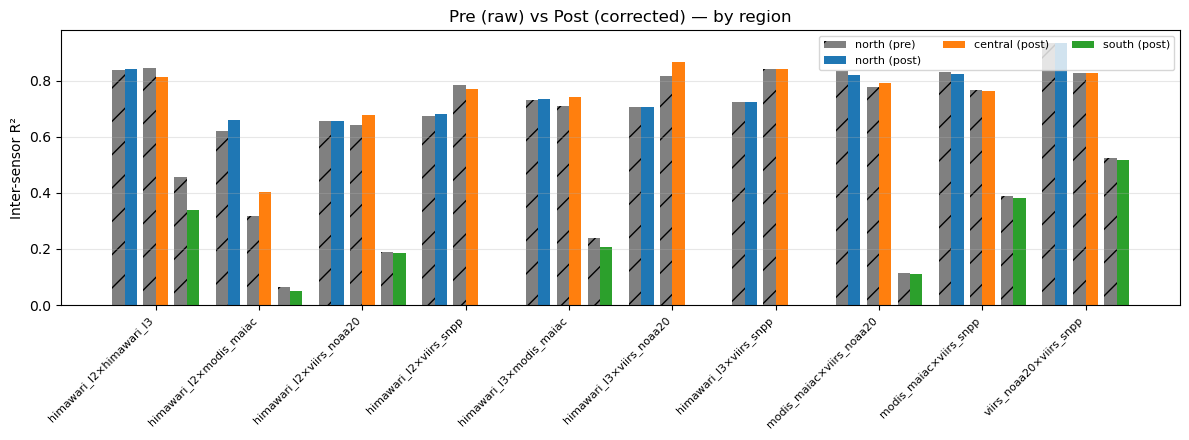

In [9]:
if not (before_df.empty or after_df.empty):
    # v3.6: L2 and L3 are kept separate in both sources; no name collapsing.
    def _canon(a, b):
        return '×'.join(sorted([a.replace('AOD_', ''), b.replace('AOD_', '')]))

    pre  = before_df.assign(source='pre',  pair=lambda d: [_canon(a,b) for a,b in zip(d['sensor_a'], d['sensor_b'])])
    post = after_df.assign( source='post', pair=lambda d: [_canon(a,b) for a,b in zip(d['sensor_a'], d['sensor_b'])])
    long = pd.concat(
        [pre [['pair','region','R2','source']],
         post[['pair','region','R2','source']]],
        ignore_index=True,
    )

    fig, ax = plt.subplots(figsize=(12, 4.5))
    pairs_axis  = sorted(long['pair'].unique())
    regions     = ['north', 'central', 'south']
    bar_w       = 0.12
    x           = np.arange(len(pairs_axis))
    for i, reg in enumerate(regions):
        for j, src in enumerate(('pre', 'post')):
            sub = long[(long['region'] == reg) & (long['source'] == src)].set_index('pair').reindex(pairs_axis)
            offset = (i - 1) * 0.30 + (j - 0.5) * bar_w
            color  = {'pre': 'gray', 'post': f'C{i}'}[src]
            hatch  = '/' if src == 'pre' else ''
            ax.bar(x + offset, sub['R2'].fillna(0).values, width=bar_w,
                   color=color, hatch=hatch, label=f'{reg} ({src})' if i == 0 or src == 'post' else None)
    ax.set_xticks(x); ax.set_xticklabels(pairs_axis, rotation=45, ha='right', fontsize=8)
    ax.set_ylabel('Inter-sensor R²'); ax.set_title('Pre (raw) vs Post (corrected) — by region')
    ax.legend(fontsize=8, ncol=3, loc='upper right')
    ax.grid(axis='y', alpha=0.3)
    fig.tight_layout(); plt.show()
